
# Introduction to Artificial Neural Networks

## What is an Artificial Neural Network?

An **Artificial Neural Network (ANN)** is a computational model designed to recognize patterns. It is composed of layers of interconnected nodes, or "neurons," which process information by transmitting signals to one another.

ANNs are the foundation of **Deep Learning**. They are capable of learning complex, non-linear relationships that traditional algorithms (like Linear Regression) struggle with. They power technologies ranging from image recognition and voice assistants to medical diagnosis systems.

## Key Components

1.  **Neurons (Nodes)**: The basic processing units. They receive inputs, perform a calculation, and produce an output.
2.  **Weights**: The connections between neurons. A "weight" determines how much influence one neuron has on the next. Learning involves adjusting these weights.
3.  **Layers**:
    -   **Input Layer**: Receives the raw data.
    -   **Hidden Layers**: Intermediate layers where the "magic" happens (feature extraction).
    -   **Output Layer**: Produces the final prediction.
4.  **Activation Function**: A mathematical gate that decides if a neuron should "fire." It introduces non-linearity, allowing the network to learn complex curves instead of just straight lines.

## Biological Inspiration

ANNs are loosely inspired by the biological neural networks in the human brain.

| Biological Neuron | Artificial Neuron      | Role                      |
|----------------- |---------------------- |------------------------- |
| **Dendrites**     | **Inputs ($x$)**       | Receives signals.         |
| **Synapse**       | **Weights ($w$)**      | Controls signal strength. |
| **Cell Body**     | **Summation ($\sum$)** | Aggregates signals.       |
| **Axon**          | **Activation**         | Transmits output.         |

## The Simplest ANN: The Perceptron

The **Perceptron** (1958) is a foundational neural network model. It is a single-layer network that takes inputs, weighs them, and makes a binary decision.

Mathematically:

1.  **Weighted Sum**: $$z = w_1 x_1 + w_2 x_2 + \dots + b$$
2.  **Activation**: $$\textrm{Output} = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z \le 0 \end{cases}$$

This simple mechanism can solve linearly separable problems (drawing a straight line between two classes).

## Limitations: The XOR Problem

Despite early hype, the single Perceptron has a fatal flaw: it cannot solve non-linear problems. The classic counter-example is the **XOR (Exclusive OR)** gate.

-   **AND Gate**: Linearly Separable (Can be solved by a line).
-   **XOR Gate**: Not Linearly Separable (Needs a curve or two lines).

This limitation highlighted the need for **Multi-Layer Perceptrons (MLPs)** and better training methods for non-linear problems.

## Practical Demonstration: Perceptron vs. MLP

We will use `scikit-learn` to demonstrate the limitation of a single neuron and the power of a network of neurons.

### The Perceptron on Logic Gates

We define the data for AND and XOR gates.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import DecisionBoundaryDisplay

sns.set_theme(style="whitegrid")

# Data
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])  # AND
y_xor = np.array([0, 1, 1, 0])  # XOR

### Training the Single Perceptron

We verify that it can learn AND but fails at XOR.

In [2]:
# Train on AND
clf_and = Perceptron(random_state=0)
clf_and.fit(X, y_and)
print(f"Perceptron AND Accuracy: {clf_and.score(X, y_and):.2f}")

# Train on XOR
clf_xor = Perceptron(random_state=0)
clf_xor.fit(X, y_xor)
print(f"Perceptron XOR Accuracy: {clf_xor.score(X, y_xor):.2f}")

Perceptron AND Accuracy: 1.00
Perceptron XOR Accuracy: 0.50


### Visualizing the Failure

The Perceptron tries to draw a straight line but fails to separate the XOR classes.

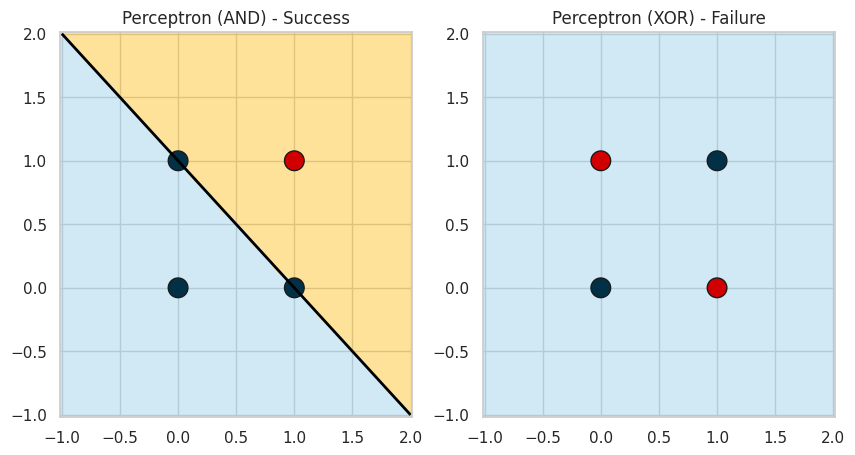

In [3]:
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
bg_cmap = ListedColormap(["#8ecae6", "#ffb703"])
pt_cmap = ListedColormap(["#023047", "#d00000"])

# Plot AND
DecisionBoundaryDisplay.from_estimator(
    clf_and,
    X,
    ax=ax[0],
    response_method="predict",
    plot_method="pcolormesh",
    cmap=bg_cmap,
    alpha=0.4
)
DecisionBoundaryDisplay.from_estimator(
    clf_and,
    X,
    ax=ax[0],
    response_method="decision_function",
    plot_method="contour",
    levels=[0],
    colors="black",
    linewidths=2
)
ax[0].scatter(X[:, 0], X[:, 1], c=y_and, cmap=pt_cmap, s=200, edgecolors='k')
ax[0].set_title("Perceptron (AND) - Success")

# Plot XOR
DecisionBoundaryDisplay.from_estimator(
    clf_xor,
    X,
    ax=ax[1],
    response_method="predict",
    plot_method="pcolormesh",
    cmap=bg_cmap,
    alpha=0.4
)
DecisionBoundaryDisplay.from_estimator(
    clf_xor,
    X,
    ax=ax[1],
    response_method="decision_function",
    plot_method="contour",
    levels=[0],
    colors="black",
    linewidths=2
)
ax[1].scatter(X[:, 0], X[:, 1], c=y_xor, cmap=pt_cmap, s=200, edgecolors='k')
ax[1].set_title("Perceptron (XOR) - Failure")

plt.show()

### The Solution: Multi-Layer Perceptron (MLP)

We use `MLPClassifier`, which adds a "Hidden Layer" of neurons. This allows the network to learn non-linear boundaries.

MLP XOR Accuracy: 1.00


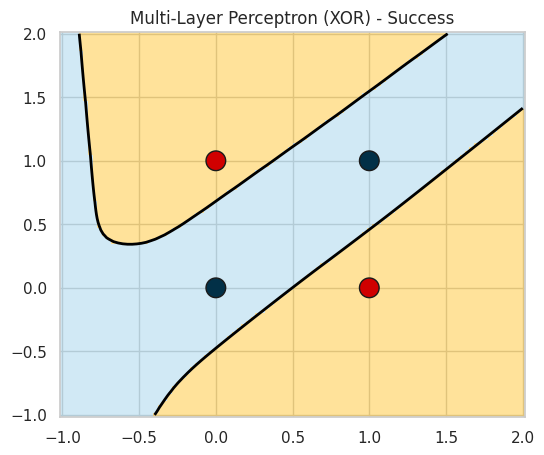

In [4]:
# For XOR, use a solver/activation combo that converges reliably on tiny datasets
mlp = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation='tanh',
    solver='lbfgs',
    alpha=1e-5,
    max_iter=5000,
    random_state=42
)
mlp.fit(X, y_xor)

print(f"MLP XOR Accuracy: {mlp.score(X, y_xor):.2f}")

# Visualize MLP Boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
DecisionBoundaryDisplay.from_estimator(
    mlp,
    X,
    ax=ax,
    response_method="predict",
    plot_method="pcolormesh",
    cmap=bg_cmap,
    alpha=0.4
)
DecisionBoundaryDisplay.from_estimator(
    mlp,
    X,
    ax=ax,
    response_method="predict_proba",
    plot_method="contour",
    levels=[0.5],
    colors="black",
    linewidths=2
)
ax.scatter(X[:, 0], X[:, 1], c=y_xor, cmap=pt_cmap, s=200, edgecolors='k')
ax.set_title("Multi-Layer Perceptron (XOR) - Success")
plt.show()

## Exercises

### Moons Dataset

The "Moons" dataset is a classic non-linear classification problem.

-   Load `make_moons`.
-   Train a `Perceptron` (Linear).
-   Train an `MLPClassifier` (Non-Linear).
-   Compare their boundaries.

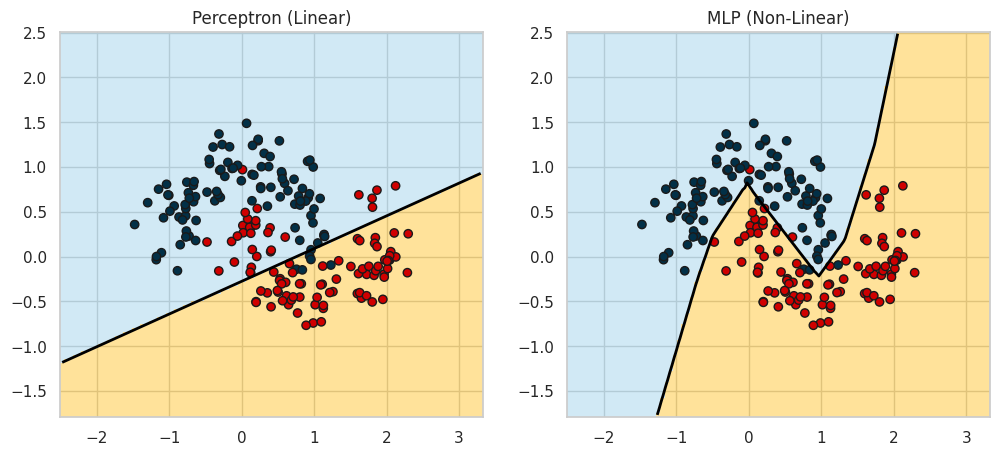

In [5]:
from sklearn.datasets import make_moons
from matplotlib.colors import ListedColormap

# Generate Data
X_moon, y_moon = make_moons(n_samples=200, noise=0.2, random_state=42)

# Train Models
perc = Perceptron(random_state=42).fit(X_moon, y_moon)
mlp_moon = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=2000, random_state=42).fit(X_moon, y_moon)

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
bg_cmap = ListedColormap(["#8ecae6", "#ffb703"])
pt_cmap = ListedColormap(["#023047", "#d00000"])

DecisionBoundaryDisplay.from_estimator(
    perc,
    X_moon,
    ax=ax[0],
    response_method="predict",
    plot_method="pcolormesh",
    cmap=bg_cmap,
    alpha=0.4
)
DecisionBoundaryDisplay.from_estimator(
    perc,
    X_moon,
    ax=ax[0],
    response_method="decision_function",
    plot_method="contour",
    levels=[0],
    colors="black",
    linewidths=2
)
ax[0].scatter(X_moon[:,0], X_moon[:,1], c=y_moon, cmap=pt_cmap, edgecolors='k')
ax[0].set_title("Perceptron (Linear)")

DecisionBoundaryDisplay.from_estimator(
    mlp_moon,
    X_moon,
    ax=ax[1],
    response_method="predict",
    plot_method="pcolormesh",
    cmap=bg_cmap,
    alpha=0.4
)
DecisionBoundaryDisplay.from_estimator(
    mlp_moon,
    X_moon,
    ax=ax[1],
    response_method="predict_proba",
    plot_method="contour",
    levels=[0.5],
    colors="black",
    linewidths=2
)
ax[1].scatter(X_moon[:,0], X_moon[:,1], c=y_moon, cmap=pt_cmap, edgecolors='k')
ax[1].set_title("MLP (Non-Linear)")

plt.show()

### Architecture Tuning

Try changing the `hidden_layer_sizes` of the MLP on the Moons dataset.

-   Try `(2,)` (Simple) vs `(100, 50)` (Complex).
-   Does the boundary become smoother or more complex?

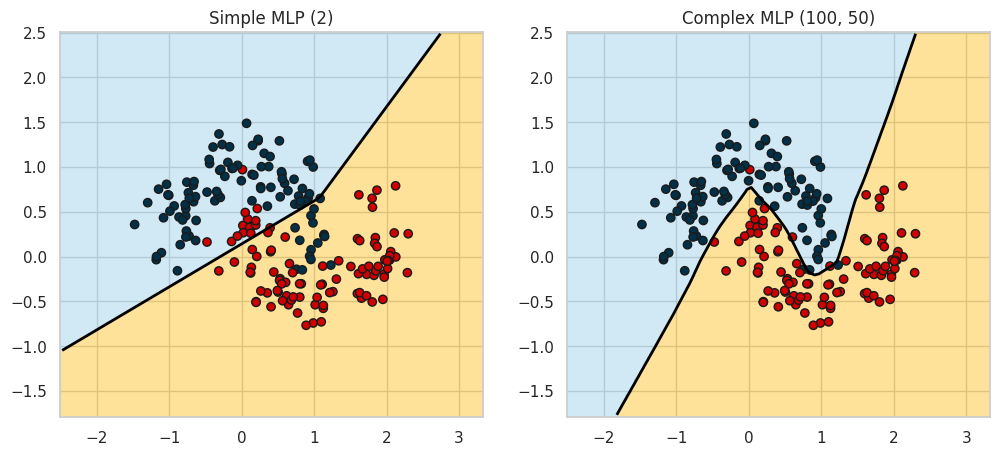

In [6]:
from matplotlib.colors import ListedColormap

mlp_simple = MLPClassifier(hidden_layer_sizes=(2,), max_iter=2000, random_state=42)
mlp_simple.fit(X_moon, y_moon)

mlp_complex = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=2000, random_state=42)
mlp_complex.fit(X_moon, y_moon)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
bg_cmap = ListedColormap(["#8ecae6", "#ffb703"])
pt_cmap = ListedColormap(["#023047", "#d00000"])

DecisionBoundaryDisplay.from_estimator(
    mlp_simple,
    X_moon,
    ax=ax[0],
    response_method="predict",
    plot_method="pcolormesh",
    cmap=bg_cmap,
    alpha=0.4
)
DecisionBoundaryDisplay.from_estimator(
    mlp_simple,
    X_moon,
    ax=ax[0],
    response_method="predict_proba",
    plot_method="contour",
    levels=[0.5],
    colors="black",
    linewidths=2
)
ax[0].scatter(X_moon[:,0], X_moon[:,1], c=y_moon, cmap=pt_cmap, edgecolors='k')
ax[0].set_title("Simple MLP (2)")

DecisionBoundaryDisplay.from_estimator(
    mlp_complex,
    X_moon,
    ax=ax[1],
    response_method="predict",
    plot_method="pcolormesh",
    cmap=bg_cmap,
    alpha=0.4
)
DecisionBoundaryDisplay.from_estimator(
    mlp_complex,
    X_moon,
    ax=ax[1],
    response_method="predict_proba",
    plot_method="contour",
    levels=[0.5],
    colors="black",
    linewidths=2
)
ax[1].scatter(X_moon[:,0], X_moon[:,1], c=y_moon, cmap=pt_cmap, edgecolors='k')
ax[1].set_title("Complex MLP (100, 50)")

plt.show()

## Summary

1.  **ANNs**: General-purpose pattern recognizers consisting of Layers, Weights, and Activation Functions.
2.  **Perceptron**: A single neuron. Fast, simple, but limited to linear problems.
3.  **MLP**: A network of neurons. Can solve non-linear problems (like XOR) by combining simple decisions into complex ones.
4.  **Activation Functions**: The key ingredient that allows networks to "bend" the decision boundary.